In [ ]:
####################################################################################
# SAAM Project 2026
# CELL 0 - SHARED IMPORTS, PATHS, CONFIG & HELPER FUNCTIONS
####################################################################################

import re
from pathlib import Path
import numpy as np
import pandas as pd
import cvxpy as cp

# ---------------------------------------------------------------------------
# PATHS  -- Path.cwd() works in Jupyter; __file__ does not
# ---------------------------------------------------------------------------
BASE_DIR  = Path.cwd()
RAW_DIR   = BASE_DIR / "raw_data"
CLEAN_DIR = BASE_DIR / "cleaned_data"
OUT_DIR   = BASE_DIR
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------
REGIONS          = ["AMER", "EUR"]
START_YEAR       = 2013
END_YEAR         = 2024
WINDOW_YEARS     = 10
MIN_VALID_MONTHS = 36      # min monthly observations required in trailing window
STALE_THRESHOLD  = 0.50    # exclude firm if >50% of window months have R == 0

# raw file names
STATIC_FILE = "Static_2025.csv"
RI_FILE     = "DS_RI_T_USD_M_2025.csv"
MV_FILE     = "DS_MV_T_USD_M_2025.csv"
CO2_FILE    = "DS_CO2_SCOPE_1_Y_2025.csv"
REV_FILE    = "DS_REV_Y_2025.csv"

# cleaned / output file names
RI_PRICES_FILE  = "cleaned_RI_monthly_prices.csv"
RI_RETURNS_FILE = "cleaned_RI_monthly_returns.csv"
MV_CLEAN_FILE   = "cleaned_MV_monthly.csv"
CO2_CLEAN_FILE  = "cleaned_CO2_scope1_yearly.csv"
REV_CLEAN_FILE  = "cleaned_REV_yearly.csv"
INV_SET_FILE    = "investment_set_by_year.csv"
MVP_W_FILE      = "mvp_weights_by_year.csv"
MVP_RET_FILE    = "mvp_monthly_returns.csv"
VW_RET_FILE     = "vw_monthly_returns.csv"

# ---------------------------------------------------------------------------
# HELPER FUNCTIONS  -- defined once, shared by all cells
# ---------------------------------------------------------------------------

def clean_headers(df):
    df.columns = [str(c).strip() for c in df.columns]
    return df

def get_id_cols(df):
    upper = {c.upper(): c for c in df.columns}
    return upper.get("NAME"), upper.get("ISIN")

def get_time_cols(df):
    name_col, isin_col = get_id_cols(df)
    exclude = {c for c in [name_col, isin_col] if c is not None}
    return [c for c in df.columns if c not in exclude]

def sort_month_cols(cols):
    try:
        dt = pd.to_datetime(cols, errors="coerce")
        if dt.notna().all():
            return [c for _, c in sorted(zip(dt, cols))]
        return sorted(cols)
    except Exception:
        return sorted(cols)

def sort_year_cols(cols):
    def parse_year(x):
        try:
            return int(str(x)[:4])
        except Exception:
            return 999999
    return sorted(cols, key=parse_year)

def get_december_col(month_cols, year):
    dts = pd.to_datetime(month_cols, errors="coerce")
    cands = [c for c, d in zip(month_cols, dts)
             if pd.notna(d) and d.year == year and d.month == 12]
    return cands[-1] if cands else None

def get_trailing_window_cols(month_cols, end_year, window_years=10):
    end_dt    = pd.Timestamp(f"{end_year}-12-31")
    start_dt  = end_dt - pd.DateOffset(years=window_years)
    col_dates = pd.to_datetime(month_cols, errors="coerce")
    return [c for c, d in zip(month_cols, col_dates)
            if pd.notna(d) and start_dt < d <= end_dt]

def get_investment_year_cols(month_cols, investment_year):
    col_dates = pd.to_datetime(month_cols, errors="coerce")
    return [c for c, d in zip(month_cols, col_dates)
            if pd.notna(d) and d.year == investment_year]

def drop_empty_timeseries_rows(df):
    # Drop rows where every time-series column is NaN
    df = clean_headers(df)
    _, isin_col = get_id_cols(df)
    time_cols = get_time_cols(df)
    df = df.dropna(subset=[isin_col]).copy()
    df[time_cols] = df[time_cols].apply(pd.to_numeric, errors="coerce")
    return df.loc[~df[time_cols].isna().all(axis=1)].copy()

def keep_isins(df, valid_isins):
    _, isin_col = get_id_cols(df)
    return df[df[isin_col].isin(valid_isins)].copy()

def annual_forward_fill(df):
    # Forward-fill missing annual values (middle/end gaps only).
    # Gaps at the beginning of the sample remain NaN -- no look-ahead.
    out = df.copy()
    year_cols = sort_year_cols(get_time_cols(out))
    out[year_cols] = out[year_cols].apply(pd.to_numeric, errors="coerce")
    out[year_cols] = out[year_cols].ffill(axis=1)
    return out

def detect_delisting(df):
    # Set RI prices to 0 from the delisting date onward.
    # Case 1: name contains explicit date, e.g. 'COMPANY DELIST 15/09/2008'
    # Case 2: name contains 'DEAD' with no date -> zero at first month after
    #         the last valid price.
    out = df.copy()
    name_col, _ = get_id_cols(out)
    if name_col is None:
        return out

    month_cols = sort_month_cols(get_time_cols(out))
    month_dts  = pd.to_datetime(month_cols, errors="coerce")

    delist_pat = re.compile(r"D(?:'|E)?LIST(?:ED)?\s*(\d{2}/\d{2}/\d{4})", re.IGNORECASE)
    dead_pat   = re.compile(r"\bDEAD\b", re.IGNORECASE)

    for idx in out.index:
        name  = str(out.at[idx, name_col])
        match = delist_pat.search(name)
        if match:
            try:
                delist_dt = pd.to_datetime(match.group(1), dayfirst=True)
            except Exception:
                continue
            for c, cdt in zip(month_cols, month_dts):
                if pd.notna(cdt) and cdt >= delist_dt:
                    out.at[idx, c] = 0.0
        elif dead_pat.search(name):
            vals       = out.loc[idx, month_cols]
            last_valid = vals.last_valid_index()
            if last_valid is not None and last_valid != month_cols[-1]:
                pos = month_cols.index(last_valid) + 1
                out.at[idx, month_cols[pos]] = 0.0
    return out

def compute_monthly_returns(ri_prices):
    # Compute simple monthly returns from cleaned RI prices.
    #   Standard:   R_t = P_t / P_{t-1} - 1
    #   Delisting:  R   = -1.0  (price goes to 0)
    #   Gap:        R   = NaN
    df = ri_prices.copy()
    name_col, isin_col = get_id_cols(df)
    month_cols   = sort_month_cols(get_time_cols(df))
    id_cols_list = [c for c in [name_col, isin_col] if c is not None]

    returns = df[id_cols_list].copy()
    for i, col in enumerate(month_cols):
        if i == 0:
            returns[col] = np.nan
            continue
        prev_col = month_cols[i - 1]
        prev = df[prev_col].values.astype(float)
        curr = df[col].values.astype(float)
        ret  = np.full(len(df), np.nan)

        valid      = (~np.isnan(prev)) & (prev > 0) & (~np.isnan(curr)) & (curr > 0)
        ret[valid] = curr[valid] / prev[valid] - 1.0

        delist      = (curr == 0.0) & (~np.isnan(prev)) & (prev > 0)
        ret[delist] = -1.0

        returns[col] = ret
    return returns

def flag_stale_prices(returns_df, end_year, window_years=10, threshold=0.50):
    # Return a DataFrame with stale-price diagnostics per firm over the
    # trailing window_years-year window ending December of end_year.
    _, isin_col = get_id_cols(returns_df)
    month_cols  = sort_month_cols(get_time_cols(returns_df))
    window_cols = get_trailing_window_cols(month_cols, end_year=end_year,
                                           window_years=window_years)
    if not window_cols:
        return pd.DataFrame(columns=["ISIN", "n_valid", "n_zero", "zero_frac", "stale_flag"])

    data      = returns_df[window_cols].apply(pd.to_numeric, errors="coerce")
    n_valid   = data.notna().sum(axis=1)
    n_zero    = (data == 0.0).sum(axis=1)
    zero_frac = n_zero / n_valid.replace(0, np.nan)

    out = pd.DataFrame({
        "ISIN":      returns_df[isin_col].values,
        "n_valid":   n_valid.values,
        "n_zero":    n_zero.values,
        "zero_frac": zero_frac.values,
    })
    out["stale_flag"] = out["zero_frac"] > threshold
    return out

def estimate_moments(ri_ret_by_isin, isins, window_cols):
    # Complete-case estimator as specified in the project:
    #   mu_Y    = (1/tau) * sum_k R_{t-k}
    #   Sigma_Y = (1/tau) * sum_k (R_{t-k} - mu_Y)(R_{t-k} - mu_Y).T
    #
    # Only firms with ZERO missing values over the full window are included.
    # This avoids pairwise covariance (which is non-PSD and requires zeroing
    # NaN off-diagonals -- an unjustified zero-correlation assumption).
    # Returns (mu, cov, valid_isins); if no complete assets: (None, None, []).
    ret_mat = (
        ri_ret_by_isin.reindex(isins)[window_cols]
        .apply(pd.to_numeric, errors="coerce")
    )
    complete_mask = ret_mat.notna().all(axis=1)
    ret_complete  = ret_mat.loc[complete_mask]
    valid_isins   = ret_complete.index.tolist()
    if not valid_isins:
        return None, None, []

    R   = ret_complete.to_numpy(dtype=float)   # shape: (N, tau)
    tau = float(R.shape[1])

    mu  = R.mean(axis=1)                       # (N,)
    R_c = R - mu[:, np.newaxis]                # demeaned: (N, tau)
    cov = (R_c @ R_c.T) / tau                 # (N, N) -- spec formula

    # Guarantee exact symmetry and PSD (clip tiny negative eigenvalues)
    cov = 0.5 * (cov + cov.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    cov = eigvecs @ np.diag(np.clip(eigvals, 1e-8, None)) @ eigvecs.T
    cov = 0.5 * (cov + cov.T)
    return mu, cov, valid_isins

def solve_mvp(cov):
    # Long-only global minimum-variance portfolio via CVXPY.
    n = cov.shape[0]
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))),
        [cp.sum(w) == 1, w >= 0]
    )
    prob.solve(solver=cp.OSQP, verbose=False)
    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"MVP optimisation failed: {prob.status}")
    weights = np.clip(np.array(w.value).flatten(), 0, None)
    return weights / weights.sum()

def summary_stats(series, name):
    ann  = 12
    vals = series.to_numpy(dtype=float)
    mu   = vals.mean()
    std  = vals.std(ddof=1)
    return {
        "portfolio":          name,
        "start_date":         series.index.min().strftime("%Y-%m"),
        "end_date":           series.index.max().strftime("%Y-%m"),
        "n_months":           len(vals),
        "ann_mean_return":    mu * ann,
        "ann_volatility":     std * np.sqrt(ann),
        "sharpe_ratio":       np.nan if std == 0 else (mu / std) * np.sqrt(ann),
        "min_monthly_return": vals.min(),
        "max_monthly_return": vals.max(),
    }

print("Cell 0 complete: helpers and config loaded.")


Cell 0 complete: helpers and config loaded.


## Section 1 — Data Cleaning

Raw Datastream files are loaded and cleaned in five steps:
1. Filter to the assigned region universe (North America + Europe)
2. Detect and handle delisted firms (price set to 0, return = -100%)
3. Treat RI prices below 0.5 as missing to avoid infinite returns
4. Forward-fill missing annual CO2 and revenue data (middle/end gaps only)
5. Intersect a common ISIN universe across all files

Note: stale-price screening is **not** applied here — it is applied year-by-year in Cell 2 to avoid any look-ahead bias.

In [ ]:
####################################################################################
# SAAM Project 2026 - Part I
# CELL 1 - DATA CLEANING
####################################################################################

# 1. LOAD RAW FILES
static = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))
ri     = clean_headers(pd.read_csv(RAW_DIR / RI_FILE))
mv     = clean_headers(pd.read_csv(RAW_DIR / MV_FILE))
co2    = clean_headers(pd.read_csv(RAW_DIR / CO2_FILE))
rev    = clean_headers(pd.read_csv(RAW_DIR / REV_FILE))

# 2. FILTER STATIC TO ASSIGNED REGIONS
static_name_col, static_isin_col = get_id_cols(static)
if static_isin_col is None:
    raise ValueError("Static file must contain an ISIN column.")
if "Region" not in static.columns:
    raise ValueError("Static file must contain a 'Region' column.")

static = static.dropna(subset=[static_isin_col]).copy()
static = static[static["Region"].isin(REGIONS)].copy()

# 3. DROP ROWS WITH NO TIME-SERIES DATA AT ALL
ri  = drop_empty_timeseries_rows(ri)
mv  = drop_empty_timeseries_rows(mv)
co2 = drop_empty_timeseries_rows(co2)
rev = drop_empty_timeseries_rows(rev)

# 4. RESTRICT TO REGION UNIVERSE
region_isins = set(static[static_isin_col])
ri  = keep_isins(ri,  region_isins)
mv  = keep_isins(mv,  region_isins)
co2 = keep_isins(co2, region_isins)
rev = keep_isins(rev, region_isins)

# 5. CLEAN RI: delisting -> low prices -> compute returns
ri_month_cols = sort_month_cols(get_time_cols(ri))
ri[ri_month_cols] = ri[ri_month_cols].apply(pd.to_numeric, errors="coerce")

# Delisting must be flagged BEFORE the low-price filter (delist sets price to exact 0)
ri = detect_delisting(ri)

# Treat prices in (0, 0.5) as missing; preserve exact 0.0 for delisted firms
for c in ri_month_cols:
    mask = (ri[c] < 0.5) & (ri[c] > 0)
    ri.loc[mask, c] = np.nan

ri     = ri.loc[~ri[ri_month_cols].isna().all(axis=1)].copy()
ri_ret = compute_monthly_returns(ri)

# 6. CLEAN MV (numeric conversion only; no fill needed for monthly data)
mv_month_cols = sort_month_cols(get_time_cols(mv))
mv[mv_month_cols] = mv[mv_month_cols].apply(pd.to_numeric, errors="coerce")

# 7. FORWARD-FILL ANNUAL DATA (middle/end gaps only; beginning gaps stay NaN)
co2 = annual_forward_fill(co2)
rev = annual_forward_fill(rev)

# 8. INTERSECT COMMON ISIN UNIVERSE ACROSS ALL FILES
_, ri_isin_col  = get_id_cols(ri)
_, mv_isin_col  = get_id_cols(mv)
_, co2_isin_col = get_id_cols(co2)
_, rev_isin_col = get_id_cols(rev)

common_isins = (
    set(static[static_isin_col])
    & set(ri[ri_isin_col])
    & set(mv[mv_isin_col])
    & set(co2[co2_isin_col])
    & set(rev[rev_isin_col])
)
# NOTE: stale-price screening is NOT applied globally here.
# It must be done year-by-year in Cell 2 to avoid look-ahead bias.

static = keep_isins(static, common_isins).sort_values(static_isin_col).reset_index(drop=True)
ri     = keep_isins(ri,     common_isins).sort_values(ri_isin_col).reset_index(drop=True)
ri_ret = keep_isins(ri_ret, common_isins).sort_values(ri_isin_col).reset_index(drop=True)
mv     = keep_isins(mv,     common_isins).sort_values(mv_isin_col).reset_index(drop=True)
co2    = keep_isins(co2,    common_isins).sort_values(co2_isin_col).reset_index(drop=True)
rev    = keep_isins(rev,    common_isins).sort_values(rev_isin_col).reset_index(drop=True)

# 9. SAVE
static.to_csv(CLEAN_DIR / "cleaned_static.csv", index=False)
ri.to_csv(    CLEAN_DIR / RI_PRICES_FILE,        index=False)
ri_ret.to_csv(CLEAN_DIR / RI_RETURNS_FILE,       index=False)
mv.to_csv(    CLEAN_DIR / MV_CLEAN_FILE,         index=False)
co2.to_csv(   CLEAN_DIR / CO2_CLEAN_FILE,        index=False)
rev.to_csv(   CLEAN_DIR / REV_CLEAN_FILE,        index=False)

print("Cell 1 - Data cleaning complete.")
print(f"  Common universe: {len(common_isins)} firms")
print(f"  Saved to: {CLEAN_DIR}")


/var/folders/3j/295v0dr15nl_1gcd4nxlgj240000gn/T/ipykernel_28330/1851594461.py:184: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns[col] = ret
/var/folders/3j/295v0dr15nl_1gcd4nxlgj240000gn/T/ipykernel_28330/1851594461.py:184: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns[col] = ret
/var/folders/3j/295v0dr15nl_1gcd4nxlgj240000gn/T/ipykernel_28330/1851594461.py:184: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consi

Cell 1 - Data cleaning complete.
  Common universe: 1209 firms
  Saved to: /Users/saarj/Documents/The Drive/UNIL Masters/Year 1/Spring Semester/Sustainability Aware Asset Management/AS- Sustainability Aware Asset Management Project /cleaned_data


## Section 2.1 — Investment Set Construction

At the end of each year Y, a firm is included in the investable universe for year Y+1 if and only if it satisfies **all four** of the following criteria:
1. Valid (strictly positive) December RI price at end of year Y
2. At least 36 months of non-missing return observations in the trailing 10-year window
3. Proportion of zero monthly returns does not exceed 50% (stale-price screen)
4. CO2 emissions data available at end of year Y (required for Part II)

The rolling window runs from end-2013 to end-2024, giving portfolios for 2014 through 2025.

In [ ]:
####################################################################################
# SAAM Project 2026 - Part I
# CELL 2 - SECTION 2.1: INVESTMENT SET
####################################################################################

ri_prices  = clean_headers(pd.read_csv(CLEAN_DIR / RI_PRICES_FILE))
ri_returns = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))
co2_clean  = clean_headers(pd.read_csv(CLEAN_DIR / CO2_CLEAN_FILE))
co2_clean.columns = [str(c) for c in co2_clean.columns]

_, ri_price_isin_col = get_id_cols(ri_prices)
_, ri_ret_isin_col   = get_id_cols(ri_returns)
_, co2_isin_col      = get_id_cols(co2_clean)

ri_month_cols = sort_month_cols(get_time_cols(ri_prices))

ri_prices_by_isin  = ri_prices.set_index(ri_price_isin_col)
ri_returns_by_isin = ri_returns.set_index(ri_ret_isin_col)
co2_by_isin        = co2_clean.set_index(co2_isin_col)

all_isins = sorted(
    set(ri_prices_by_isin.index)
    & set(ri_returns_by_isin.index)
    & set(co2_by_isin.index)
)

investment_tables = []

for year in range(START_YEAR, END_YEAR + 1):
    dec_col = get_december_col(ri_month_cols, year)
    if dec_col is None:
        print(f"  {year}: no December column found, skipping.")
        continue

    stale_info = flag_stale_prices(
        ri_returns, end_year=year,
        window_years=WINDOW_YEARS, threshold=STALE_THRESHOLD
    ).set_index("ISIN")

    if stale_info.empty:
        print(f"  {year}: stale-price window empty, skipping.")
        continue

    screen = pd.DataFrame(index=all_isins)
    screen.index.name = "ISIN"

    # (a) valid December RI price (strictly positive; exact 0 means delisted)
    dec_price = pd.to_numeric(ri_prices_by_isin[dec_col], errors="coerce")
    screen["has_valid_dec_price"] = dec_price.notna() & (dec_price > 0)

    # (b) minimum return history in trailing window
    screen["n_valid_return_months"] = stale_info["n_valid"]
    screen["has_min_history"]       = screen["n_valid_return_months"] >= MIN_VALID_MONTHS

    # (c) stale-price screen
    screen["zero_return_fraction"] = stale_info["zero_frac"]
    screen["stale_flag"]           = stale_info["stale_flag"]

    # (d) CO2 data available at end of year Y (required for Part II)
    year_str = str(year)
    if year_str in co2_by_isin.columns:
        screen["has_co2_at_year_end"] = (
            pd.to_numeric(co2_by_isin[year_str], errors="coerce").notna()
        )
    else:
        screen["has_co2_at_year_end"] = False

    screen["investable_for_next_year"] = (
        screen["has_valid_dec_price"]
        & screen["has_min_history"]
        & (~screen["stale_flag"])
        & screen["has_co2_at_year_end"]
    )

    screen = screen.reset_index()
    screen["screen_year"]     = year
    screen["investment_year"] = year + 1
    investment_tables.append(screen)

    n_inv = screen["investable_for_next_year"].sum()
    print(f"  {year}: {n_inv} investable firms for {year + 1}")

investment_set = (
    pd.concat(investment_tables, ignore_index=True)
    if investment_tables else pd.DataFrame()
)
investment_set.to_csv(OUT_DIR / INV_SET_FILE, index=False)

summary_by_year = (
    investment_set.groupby("screen_year")["investable_for_next_year"]
    .sum().rename("n_investable")
)
print("\nCell 2 complete. Investable firms by year:")
print(summary_by_year.to_string())


  2013: 829 investable firms for 2014
  2014: 853 investable firms for 2015
  2015: 885 investable firms for 2016
  2016: 909 investable firms for 2017
  2017: 941 investable firms for 2018
  2018: 998 investable firms for 2019
  2019: 1087 investable firms for 2020
  2020: 1130 investable firms for 2021
  2021: 1162 investable firms for 2022
  2022: 1162 investable firms for 2023
  2023: 1147 investable firms for 2024
  2024: 1132 investable firms for 2025

Cell 2 complete. Investable firms by year:
screen_year
2013     829
2014     853
2015     885
2016     909
2017     941
2018     998
2019    1087
2020    1130
2021    1162
2022    1162
2023    1147
2024    1132


## Section 2.2 — Minimum Variance Portfolio

At the end of each year Y, the long-only global minimum variance portfolio is solved:

$$\min_{\alpha_Y} \; \alpha_Y' \Sigma_Y \alpha_Y \quad \text{s.t.} \quad \alpha_Y' e = 1, \quad \alpha_{i,Y} \geq 0$$

The covariance matrix uses the **complete-case** estimator from the project spec — only firms with zero missing returns over the full 10-year window are included. This avoids pairwise covariance (non-PSD) and NaN-zeroing heuristics.

In [ ]:
####################################################################################
# SAAM Project 2026 - Part I
# CELL 3 - SECTION 2.2: MINIMUM VARIANCE PORTFOLIO WEIGHTS
####################################################################################

ri_returns      = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))
_, ret_isin_col  = get_id_cols(ri_returns)
ret_month_cols   = sort_month_cols(get_time_cols(ri_returns))
ri_ret_by_isin   = ri_returns.set_index(ret_isin_col)

investment_set   = clean_headers(pd.read_csv(OUT_DIR / INV_SET_FILE))

weights_rows      = []
year_summary_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year)
        & investment_set["investable_for_next_year"],
        "ISIN"
    ].tolist()

    if not investable_isins:
        print(f"  {year}: no investable firms, skipping.")
        continue

    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year,
                                           window_years=WINDOW_YEARS)
    if not window_cols:
        print(f"  {year}: no trailing window columns, skipping.")
        continue

    # --- COMPLETE-CASE moment estimation (project spec formula) ---
    # Only firms with zero NaN values over the full window are used.
    # This is consistent with the spec estimator and avoids:
    #   (i)  pairwise .cov() which produces non-PSD matrices when assets
    #         have different missing-data patterns
    #   (ii) zeroing NaN off-diagonals (an unjustified zero-correlation assumption)
    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)

    if not valid_isins:
        print(f"  {year}: no complete-case assets available, skipping.")
        continue

    weights = solve_mvp(cov)

    for isin, w in zip(valid_isins, weights):
        weights_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "ISIN":            isin,
            "weight":          w,
        })

    year_summary_rows.append({
        "screen_year":       year,
        "investment_year":   investment_year,
        "n_investable":      len(investable_isins),
        "n_assets_in_cov":   len(valid_isins),
        "n_dropped_missing": len(investable_isins) - len(valid_isins),
        "max_weight":        float(weights.max()),
    })
    print(f"  {year}: investable={len(investable_isins)}, "
          f"used in cov={len(valid_isins)}, max_w={weights.max():.4f}")

weights_by_year = pd.DataFrame(weights_rows)
weights_by_year.to_csv(OUT_DIR / MVP_W_FILE, index=False)
pd.DataFrame(year_summary_rows).to_csv(OUT_DIR / "mvp_weights_summary_by_year.csv", index=False)

print(f"\nCell 3 complete. MVP weights saved ({len(weights_rows)} rows).")


  2013: investable=829, used in cov=771, max_w=0.1161
  2014: investable=853, used in cov=811, max_w=0.1325
  2015: investable=885, used in cov=862, max_w=0.1213
  2016: investable=909, used in cov=895, max_w=0.1380
  2017: investable=941, used in cov=931, max_w=0.1140
  2018: investable=998, used in cov=984, max_w=0.1208
  2019: investable=1087, used in cov=1073, max_w=0.0682
  2020: investable=1130, used in cov=1115, max_w=0.1274
  2021: investable=1162, used in cov=1148, max_w=0.0923
  2022: investable=1162, used in cov=1147, max_w=0.0919
  2023: investable=1147, used in cov=1136, max_w=0.1147
  2024: investable=1132, used in cov=1120, max_w=0.1140

Cell 3 complete. MVP weights saved (11993 rows).


## Section 2.2–2.3 — Out-of-Sample Returns and Benchmark Comparison

Weights from end of year Y are held for all 12 months of year Y+1, drifting as:

$$\alpha_{i,t+1} = \alpha_{i,t} \cdot \frac{1 + R_{i,t+1}}{1 + R_{p,t+1}}$$

The value-weighted benchmark uses beginning-of-month market caps as weights over the same investable universe.

**Outputs:** Table 1 (performance summary), Table 2 (universe size by year), Table 3 (top 10 MVP holdings), Figure 1 (cumulative returns).


Table 1 — Performance Summary: MVP vs Value-Weighted Benchmark
          Period: Jan 2014 to Oct 2025
Portfolio Ann. Return Ann. Volatility Sharpe Ratio Min Monthly Ret. Max Monthly Ret.
P(mv)_oos       9.90%          10.99%        0.901           -6.31%            7.49%
P(vw)_oos      15.58%          13.83%        1.126           -7.82%           12.88%
Note: Sharpe ratio = (mu_monthly / sigma_monthly) x sqrt(12), Rf = 0.
      Annualised return = monthly mean x 12. Volatility = monthly std x sqrt(12).

Table 2 — Investable Universe by Year
 Screen Year  N Firms
        2013      829
        2014      853
        2015      885
        2016      909
        2017      941
        2018      998
        2019     1087
        2020     1130
        2021     1162
        2022     1162
        2023     1147
        2024     1132
Note: firms must satisfy all four criteria at end of year Y:
  (1) valid December RI price  (2) >= 36 months return history
  (3) stale-price fraction <= 50%  (4) CO

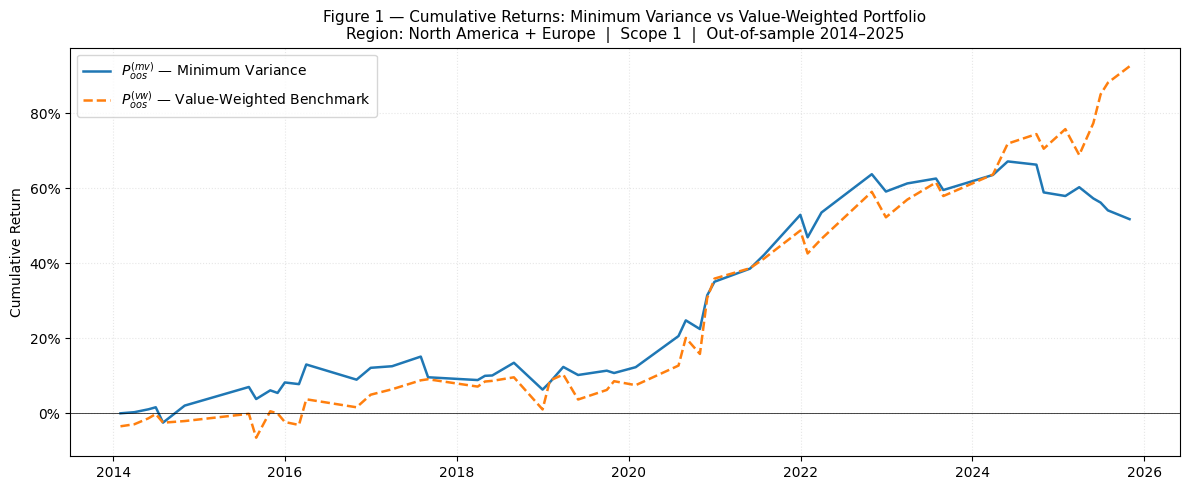

Figure 1 saved.

Cell 4 complete.


In [ ]:
####################################################################################
# SAAM Project 2026 - Part I
# CELL 4 - SECTION 2.2 (OOS returns) & 2.3 (value-weighted benchmark + comparison)
####################################################################################

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ri_returns      = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))
_, ret_isin_col  = get_id_cols(ri_returns)
ret_month_cols   = sort_month_cols(get_time_cols(ri_returns))
ri_ret_by_isin   = ri_returns.set_index(ret_isin_col)

mv_clean         = clean_headers(pd.read_csv(CLEAN_DIR / MV_CLEAN_FILE))
_, mv_isin_col   = get_id_cols(mv_clean)
mv_month_cols    = sort_month_cols(get_time_cols(mv_clean))
mv_by_isin       = mv_clean.set_index(mv_isin_col)

weights_by_year  = clean_headers(pd.read_csv(OUT_DIR / MVP_W_FILE))
investment_set   = clean_headers(pd.read_csv(OUT_DIR / INV_SET_FILE))

# ── 4A. MVP monthly out-of-sample returns ────────────────────────────────────
mvp_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1
    year_w = weights_by_year[weights_by_year["screen_year"] == year].copy()
    if year_w.empty:
        continue

    asset_list = year_w["ISIN"].tolist()
    alpha      = year_w["weight"].to_numpy(dtype=float)
    inv_cols   = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    # Missing returns within the investment year are filled with 0.
    # These are mid-year data gaps; delistings were handled in Cell 1 (-100%).
    inv_ret = (
        ri_ret_by_isin.reindex(asset_list)[inv_cols]
        .apply(pd.to_numeric, errors="coerce")
        .fillna(0.0)
        .to_numpy(dtype=float)
    )

    for k, col in enumerate(inv_cols):
        rt = inv_ret[:, k]
        rp = float(alpha @ rt)
        mvp_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "date":            pd.Timestamp(col),
            "Rp_mvp":          rp,
        })
        # Drift weights within the year: alpha_{t+1} = alpha_t * (1+R_i) / (1+R_p)
        denom = 1.0 + rp
        if abs(denom) < 1e-12:
            alpha = np.ones_like(alpha) / len(alpha)
        else:
            alpha = alpha * (1.0 + rt) / denom
            alpha = np.clip(alpha, 0.0, None)
            s = alpha.sum()
            alpha = (np.ones_like(alpha) / len(alpha)) if s <= 1e-12 else alpha / s

mvp_monthly_returns = (
    pd.DataFrame(mvp_rows).sort_values("date").reset_index(drop=True)
)
if mvp_monthly_returns.empty:
    raise RuntimeError("No MVP monthly returns generated.")
# ── 4B. Value-weighted benchmark ─────────────────────────────────────────────
vw_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year)
        & investment_set["investable_for_next_year"],
        "ISIN"
    ].tolist()
    if not investable_isins:
        continue

    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    for col in inv_cols:
        current_dt    = pd.Timestamp(col)
        prev_month_dt = current_dt - pd.DateOffset(months=1)
        prev_candidates = [c for c in mv_month_cols if pd.Timestamp(c) == prev_month_dt]
        if not prev_candidates:
            continue
        prev_col = prev_candidates[0]

        caps = (
            mv_by_isin.reindex(investable_isins)[prev_col]
            .apply(pd.to_numeric, errors="coerce")
        )
        rets = (
            ri_ret_by_isin.reindex(investable_isins)[col]
            .apply(pd.to_numeric, errors="coerce")
            .fillna(0.0)
        )
        valid = caps.notna() & (caps > 0)
        caps, rets = caps[valid], rets[valid]
        if caps.empty:
            continue

        weights_vw = caps / caps.sum()
        vw_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "date":            current_dt,
            "Rp_vw":           float((weights_vw * rets).sum()),
        })

vw_monthly_returns = (
    pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)
)
if vw_monthly_returns.empty:
    raise RuntimeError("No VW monthly returns generated.")
# ── 4C. Merge & cumulative returns ───────────────────────────────────────────
_merged = (
    mvp_monthly_returns[["date", "Rp_mvp"]]
    .assign(date=lambda d: pd.to_datetime(d["date"]))
    .merge(
        vw_monthly_returns[["date", "Rp_vw"]]
        .assign(date=lambda d: pd.to_datetime(d["date"])),
        on="date", how="inner"
    )
    .sort_values("date")
    .set_index("date")
)

if _merged.empty:
    raise RuntimeError("Merged comparison dataframe is empty.")

_merged["cum_mvp"] = (1.0 + _merged["Rp_mvp"]).cumprod() - 1.0
_merged["cum_vw"]  = (1.0 + _merged["Rp_vw"]).cumprod()  - 1.0
# ── 4D. Summary statistics ───────────────────────────────────────────────────
mvp_stats = summary_stats(_merged["Rp_mvp"], "P(mv)_oos")
vw_stats  = summary_stats(_merged["Rp_vw"],  "P(vw)_oos")
comparison_summary = pd.DataFrame([mvp_stats, vw_stats])

# ── 4E. TABLE 1 — Performance summary (inline) ───────────────────────────────
display_df = comparison_summary[
    ["portfolio", "ann_mean_return", "ann_volatility",
     "sharpe_ratio", "min_monthly_return", "max_monthly_return"]
].copy()
display_df.columns = [
    "Portfolio", "Ann. Return", "Ann. Volatility",
    "Sharpe Ratio", "Min Monthly Ret.", "Max Monthly Ret."
]
for col in ["Ann. Return", "Ann. Volatility", "Min Monthly Ret.", "Max Monthly Ret."]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")
display_df["Sharpe Ratio"] = display_df["Sharpe Ratio"].apply(lambda x: f"{x:.3f}")

print("\n" + "=" * 72)
print("Table 1 — Performance Summary: MVP vs Value-Weighted Benchmark")
print(f"          Period: {_merged.index.min().strftime('%b %Y')} "
      f"to {_merged.index.max().strftime('%b %Y')}")
print("=" * 72)
print(display_df.to_string(index=False))
print("=" * 72)
print("Note: Sharpe ratio = (mu_monthly / sigma_monthly) x sqrt(12), Rf = 0.")
print("      Annualised return = monthly mean x 12. Volatility = monthly std x sqrt(12).")

# ── 4F. TABLE 2 — Investable universe size by year (inline) ──────────────────
inv_by_year = (
    investment_set[investment_set["investable_for_next_year"]]
    .groupby("screen_year")["ISIN"].count()
    .rename("N Firms")
    .reset_index()
    .rename(columns={"screen_year": "Screen Year"})
)

print("\n" + "=" * 35)
print("Table 2 — Investable Universe by Year")
print("=" * 35)
print(inv_by_year.to_string(index=False))
print("=" * 35)
print("Note: firms must satisfy all four criteria at end of year Y:\n"
      "  (1) valid December RI price  (2) >= 36 months return history\n"
      "  (3) stale-price fraction <= 50%  (4) CO2 data available")

# ── 4G. TABLE 3 — Top 10 MVP holdings for first investment year (inline) ─────
first_screen_year = weights_by_year["screen_year"].min()
top10 = (
    weights_by_year[weights_by_year["screen_year"] == first_screen_year]
    .nlargest(10, "weight")[["ISIN", "weight"]]
    .copy()
    .reset_index(drop=True)
)
top10.index = range(1, 11)
top10["weight"] = top10["weight"].apply(lambda x: f"{x:.2%}")

print(f"\n" + "=" * 45)
print(f"Table 3 — Top 10 MVP Holdings "
      f"(portfolio for {first_screen_year + 1})")
print("=" * 45)
print(top10.to_string(columns=["ISIN", "weight"]))
print("=" * 45)
print(f"Note: weights optimised at end of {first_screen_year} using the\n"
      f"      10-year trailing covariance (complete-case estimator,\n"
      f"      long-only constraint, no short selling).")

# ── 4H. FIGURE 1 — Cumulative returns (inline) ───────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(_merged.index, _merged["cum_mvp"],
        label=r"$P^{(mv)}_{oos}$ — Minimum Variance", linewidth=1.8)
ax.plot(_merged.index, _merged["cum_vw"],
        label=r"$P^{(vw)}_{oos}$ — Value-Weighted Benchmark",
        linewidth=1.8, linestyle="--")

ax.set_title(
    "Figure 1 — Cumulative Returns: Minimum Variance vs Value-Weighted Portfolio\n"
    "Region: North America + Europe  |  Scope 1  |  Out-of-sample 2014–2025",
    fontsize=11
)
ax.set_ylabel("Cumulative Return")
ax.set_xlabel("")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3, linestyle=":")
ax.axhline(0, color="black", linewidth=0.5)

fig.tight_layout()
plt.show()

print("\nCell 4 complete.")
